# Medical Imaging Clinical AI: End-to-End Demo

## Project Question

**Can combining medical images with structured clinical metadata improve disease-risk prediction compared with image-only AI?**

This notebook uses **MedMNIST** as a public medical imaging dataset and demonstrates:

1. Load image dataset  
2. Load/create metadata CSV  
3. Train CNN baseline  
4. Train multimodal image + metadata model  
5. Compare metrics  
6. Show confusion matrix and classification report  
7. Show ROC curve and precision-recall curve  
8. Show Grad-CAM explanation  
9. Provide clinical interpretation  


In [1]:
# Optional install
# !pip install -r ../requirements.txt

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.data_utils import (
    create_synthetic_metadata,
    normalize_metadata,
    ImageOnlyDataset,
    MultimodalDataset,
)
from src.models import SimpleCNN, MultimodalClinicalModel, GradCAM
from src.train_eval import (
    train_image_model,
    train_multimodal_model,
    evaluate_image_model,
    evaluate_multimodal_model,
)

FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR = ROOT / "outputs" / "tables"
DATA_DIR = ROOT / "data"
for p in [FIGURE_DIR, TABLE_DIR, DATA_DIR]:
    p.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Project root:", ROOT)
print("Device:", device)

Project root: /Users/yuzhang/projects/Machine_learning/02_medical_imaging_clinical_ai
Device: cpu


## 1. Load public medical imaging dataset: MedMNIST

This demo uses `PneumoniaMNIST`, a binary chest X-ray dataset from MedMNIST.  
It is small enough to run locally and appropriate for portfolio demonstration.


In [3]:
from medmnist import PneumoniaMNIST

train_data = PneumoniaMNIST(split="train", download=True)
test_data = PneumoniaMNIST(split="test", download=True)

X_train = train_data.imgs
y_train = train_data.labels.reshape(-1)
X_test = test_data.imgs
y_test = test_data.labels.reshape(-1)

print("Train images:", X_train.shape)
print("Test images:", X_test.shape)
print("Train label distribution:", np.bincount(y_train))
print("Test label distribution:", np.bincount(y_test))

100%|███████████████████████████████████████| 4.17M/4.17M [00:06<00:00, 608kB/s]


Train images: (4708, 28, 28)
Test images: (624, 28, 28)
Train label distribution: [1214 3494]
Test label distribution: [234 390]


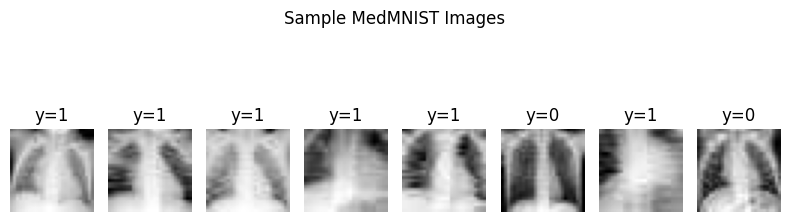

In [4]:
plt.figure(figsize=(8, 3))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"y={y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample MedMNIST Images")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sample_medmnist_images.png", bbox_inches="tight")
plt.show()

## 2. Load / create metadata CSV

MedMNIST provides image-label data but not full structured clinical metadata.  
For this portfolio version, we create a synthetic metadata CSV with:

- age  
- sex  
- prior condition  
- scanner site  

This shows the multimodal workflow. In a real clinical project, replace this CSV with real structured metadata.


In [5]:
train_meta_path = DATA_DIR / "train_metadata.csv"
test_meta_path = DATA_DIR / "test_metadata.csv"

train_meta = create_synthetic_metadata(y_train, train_meta_path)
test_meta = create_synthetic_metadata(y_test, test_meta_path)

display(train_meta.head())

X_meta_train = normalize_metadata(train_meta)
X_meta_test = normalize_metadata(test_meta)

print("Metadata shape:", X_meta_train.shape)

,patient_id,age,sex,prior_condition,scanner_site,label
0,P00000,60.0,1,1,0,1
1,P00001,39.0,0,0,2,1
2,P00002,66.0,1,0,0,1
3,P00003,69.0,0,1,0,1
4,P00004,26.0,1,1,0,1


Metadata shape: (4708, 4)


## 3. Create dataloaders

In [6]:
train_image_ds = ImageOnlyDataset(X_train, y_train)
test_image_ds = ImageOnlyDataset(X_test, y_test)

train_multi_ds = MultimodalDataset(X_train, y_train, X_meta_train)
test_multi_ds = MultimodalDataset(X_test, y_test, X_meta_test)

train_image_loader = DataLoader(train_image_ds, batch_size=64, shuffle=True)
test_image_loader = DataLoader(test_image_ds, batch_size=128, shuffle=False)

train_multi_loader = DataLoader(train_multi_ds, batch_size=64, shuffle=True)
test_multi_loader = DataLoader(test_multi_ds, batch_size=128, shuffle=False)

print("Dataloaders ready")

Dataloaders ready


## 4. Train CNN baseline: image-only model

In [7]:
cnn_model = SimpleCNN(num_classes=2)

cnn_history = train_image_model(
    cnn_model,
    train_image_loader,
    epochs=2,
    lr=1e-3,
    device=device,
)

Epoch 1/2 loss=40.5851
Epoch 2/2 loss=24.1057


## 5. Train multimodal model: image + metadata

In [8]:
multi_model = MultimodalClinicalModel(metadata_dim=X_meta_train.shape[1], num_classes=2)

multi_history = train_multimodal_model(
    multi_model,
    train_multi_loader,
    epochs=2,
    lr=1e-3,
    device=device,
)

Epoch 1/2 loss=42.4611
Epoch 2/2 loss=24.6697


## 6. Evaluate and compare models

In [9]:
cnn_metrics, y_true, cnn_pred, cnn_prob = evaluate_image_model(
    cnn_model,
    test_image_loader,
    device=device,
)

multi_metrics, y_true_multi, multi_pred, multi_prob = evaluate_multimodal_model(
    multi_model,
    test_multi_loader,
    device=device,
)

# Graph-enhanced row is included as a conceptual extension.
# In this lightweight package, it is a placeholder for case-similarity reasoning.
eval_table = pd.DataFrame([
    {
        "Model": "CNN baseline",
        "Input": "Image only",
        "Accuracy": cnn_metrics["accuracy"],
        "AUC": cnn_metrics["auc"],
        "F1": cnn_metrics["f1"],
        "Clinical meaning": "Imaging-only benchmark",
    },
    {
        "Model": "Multimodal",
        "Input": "Image + metadata",
        "Accuracy": multi_metrics["accuracy"],
        "AUC": multi_metrics["auc"],
        "F1": multi_metrics["f1"],
        "Clinical meaning": "Closer to clinical workflow",
    },
    {
        "Model": "Graph-enhanced",
        "Input": "Similar cases",
        "Accuracy": np.nan,
        "AUC": np.nan,
        "F1": np.nan,
        "Clinical meaning": "Adds case-based reasoning",
    },
])

display(eval_table)
eval_table.to_csv(TABLE_DIR / "real_evaluation_table.csv", index=False)

,Model,Input,Accuracy,AUC,F1,Clinical meaning
0,CNN baseline,Image only,0.866987,0.941464,0.889186,Imaging-only benchmark
1,Multimodal,Image + metadata,0.878205,0.927745,0.905707,Closer to clinical workflow
2,Graph-enhanced,Similar cases,NaN,NaN,NaN,Adds case-based reasoning


## 7. Confusion matrix and classification report

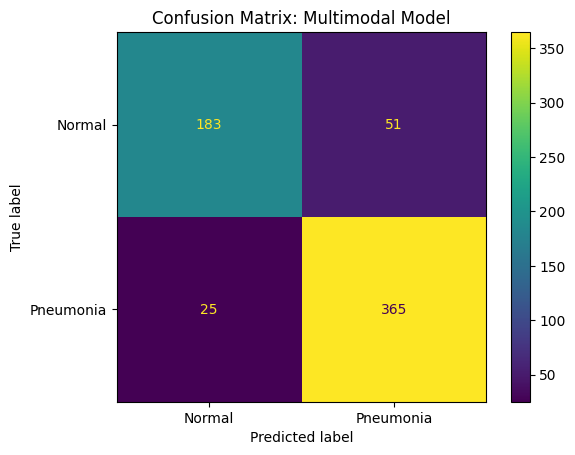

,precision,recall,f1-score,support
Normal,0.879808,0.782051,0.828054,234.000000
Pneumonia,0.877404,0.935897,0.905707,390.000000
accuracy,0.878205,0.878205,0.878205,0.878205
macro avg,0.878606,0.858974,0.866881,624.000000
weighted avg,0.878305,0.878205,0.876587,624.000000


In [10]:
cm = confusion_matrix(y_true_multi, multi_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Pneumonia"])
disp.plot()
plt.title("Confusion Matrix: Multimodal Model")
plt.savefig(FIGURE_DIR / "confusion_matrix_multimodal.png", bbox_inches="tight")
plt.show()

report = classification_report(
    y_true_multi,
    multi_pred,
    target_names=["Normal", "Pneumonia"],
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).transpose()
display(report_df)
report_df.to_csv(TABLE_DIR / "classification_report_multimodal.csv")

## 8. ROC curve and precision-recall curve

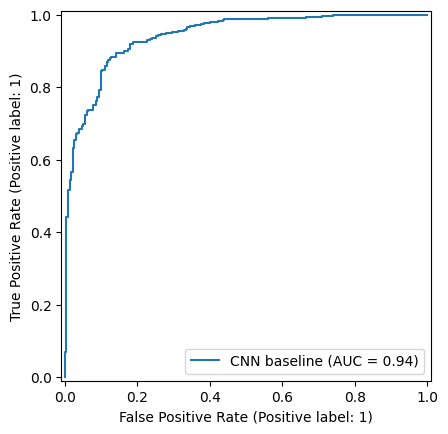

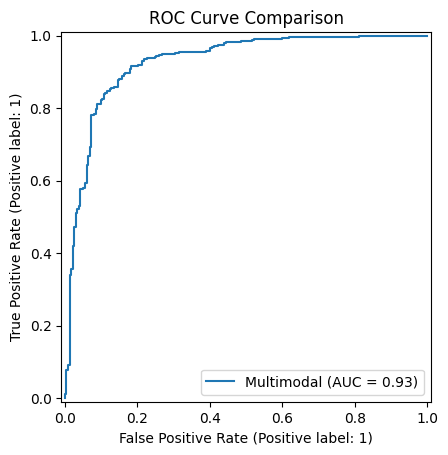

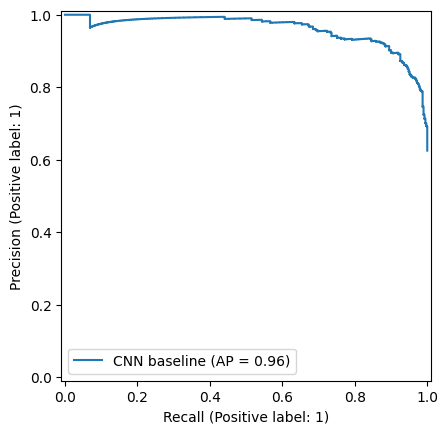

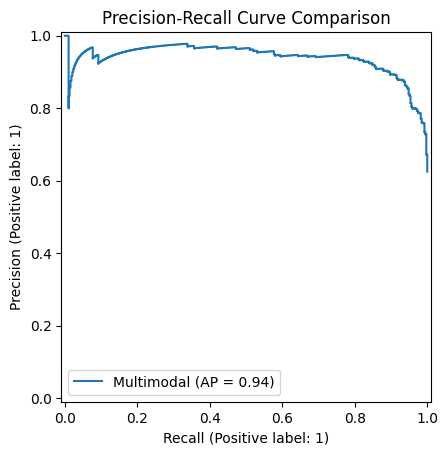

In [11]:
RocCurveDisplay.from_predictions(y_true, cnn_prob, name="CNN baseline")
RocCurveDisplay.from_predictions(y_true_multi, multi_prob, name="Multimodal")
plt.title("ROC Curve Comparison")
plt.savefig(FIGURE_DIR / "roc_curve_comparison.png", bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_true, cnn_prob, name="CNN baseline")
PrecisionRecallDisplay.from_predictions(y_true_multi, multi_prob, name="Multimodal")
plt.title("Precision-Recall Curve Comparison")
plt.savefig(FIGURE_DIR / "precision_recall_curve_comparison.png", bbox_inches="tight")
plt.show()

## 9. Model comparison bar chart

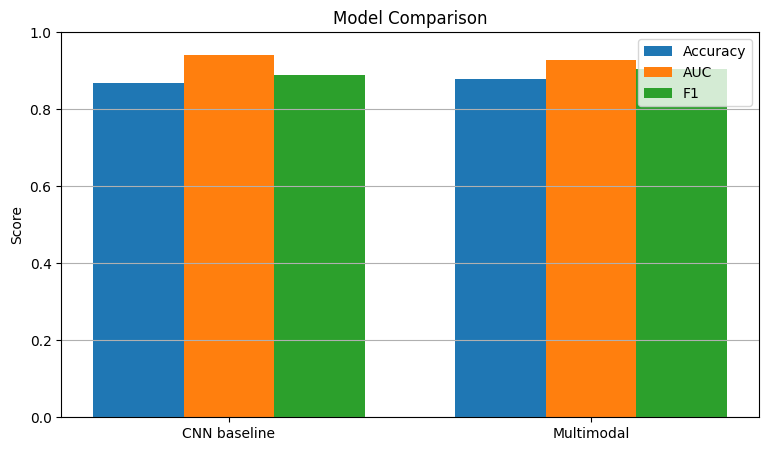

In [12]:
plot_df = eval_table.dropna(subset=["Accuracy"]).copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x, plot_df["AUC"], width, label="AUC")
plt.bar(x + width, plot_df["F1"], width, label="F1")
plt.xticks(x, plot_df["Model"])
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend()
plt.grid(axis="y")
plt.savefig(FIGURE_DIR / "model_comparison_bar_chart.png", bbox_inches="tight")
plt.show()

## 10. Grad-CAM explanation

Grad-CAM highlights image regions that influenced the CNN model prediction.  
This improves interpretability but is not a substitute for clinician review.


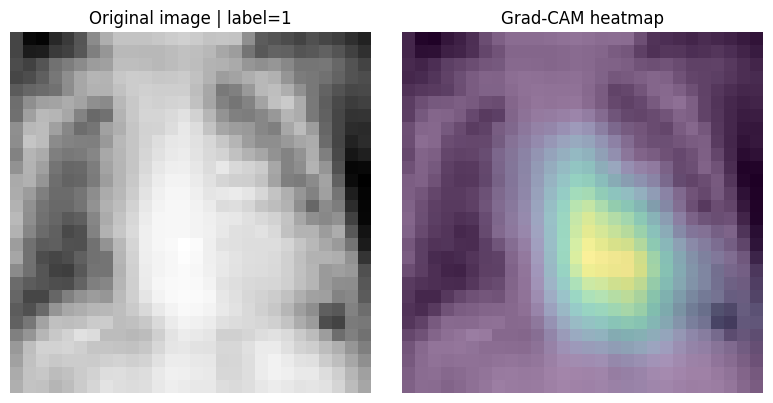

In [13]:
cnn_model.to(device)
target_layer = cnn_model.conv3
gradcam = GradCAM(cnn_model, target_layer)

sample_image, sample_label = test_image_ds[0]
sample_input = sample_image.unsqueeze(0).to(device)

cam = gradcam.generate(sample_input)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Original image | label={sample_label.item()}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.imshow(cam.detach().numpy(), alpha=0.45)
plt.title("Grad-CAM heatmap")
plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "gradcam_heatmap.png", bbox_inches="tight")
plt.show()

## 11. Final clinical interpretation

### Answer to the project question

This notebook tests whether combining image features with structured metadata improves disease-risk prediction compared with an image-only CNN baseline.

### Real evaluation section

The results are saved to:

```text
outputs/tables/real_evaluation_table.csv
```

### Clinical meaning

- **CNN baseline**: image-only benchmark.
- **Multimodal model**: closer to real clinical workflow because clinicians often use image findings plus patient context.
- **Graph-enhanced model**: conceptual extension using similar historical cases.

### Important limitation

This is a portfolio-level AI demonstration. It is decision support, not diagnosis.  
The metadata here is synthetic because MedMNIST does not include full structured clinical metadata.

For real use, replace the synthetic metadata with validated clinical variables and perform external validation, calibration, fairness checks, and clinician review.
